# Analyse Recordings Stats

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Suppress Python warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np

# local imports
from lib_henryk_analysis.logger import *
from lib_henryk_analysis.config import *
from lib_henryk_analysis.recordings import recordings

2026-01-05 07:55:25.328 | INFO     | lib_henryk_analysis.config:<module>:92 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-analysis


In [4]:
# load data
df = pd.read_parquet(FILE_RECORDINGS_STATS_PARQUET)

# convert date
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')  

## Generate Plots

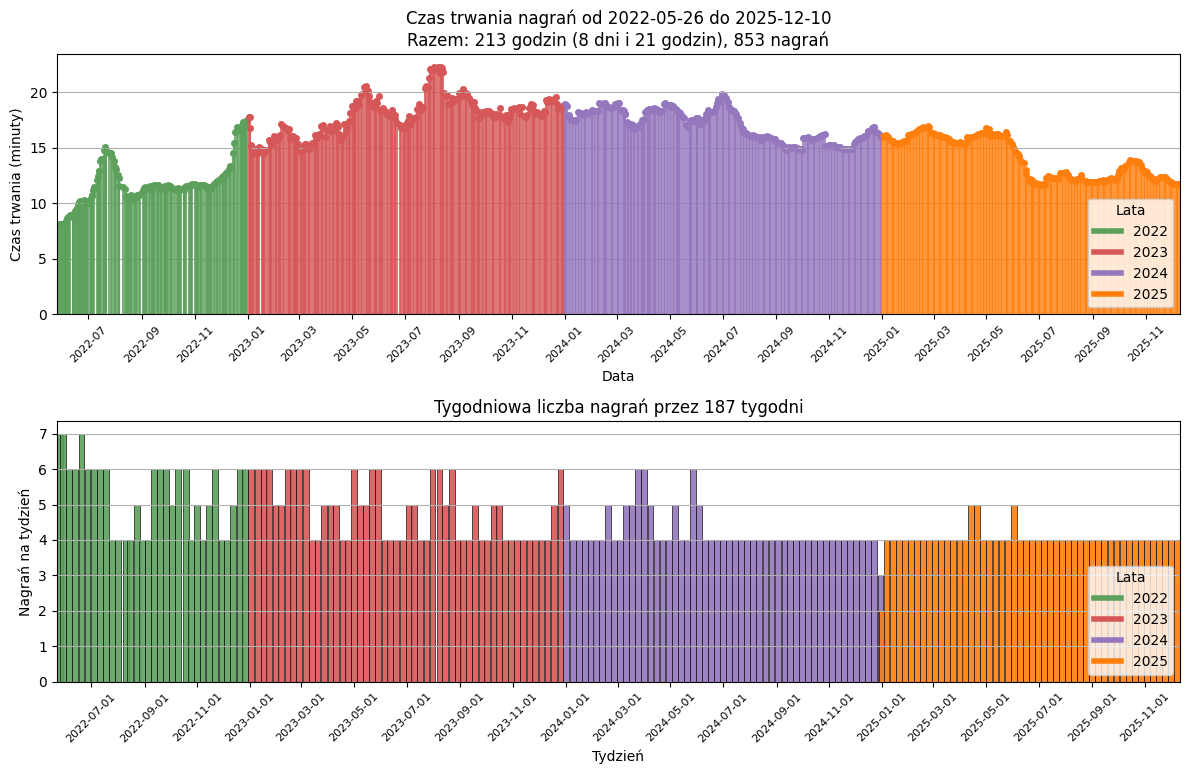

In [5]:
recordings.plot_recordings_stats(df, language='pl')

## Run Gaps Analysis

In [6]:
recordings.analyze_and_print_gaps(df)

Analyzing temporal data for discontinuities...
Located 15 temporal discontinuities exceeding 1 days:
Gap 1:
  Start: 2022-06-10 00:00:00
  End:   2022-06-13 00:00:00
  Duration: 2.00 days
------------------------------------------------------------
Gap 2:
  Start: 2022-07-08 00:00:00
  End:   2022-07-11 00:00:00
  Duration: 2.00 days
------------------------------------------------------------
Gap 3:
  Start: 2022-07-22 00:00:00
  End:   2022-07-25 00:00:00
  Duration: 2.00 days
------------------------------------------------------------
Gap 4:
  Start: 2022-08-06 00:00:00
  End:   2022-08-10 00:00:00
  Duration: 3.00 days
------------------------------------------------------------
Gap 5:
  Start: 2022-08-26 00:00:00
  End:   2022-08-29 00:00:00
  Duration: 2.00 days
------------------------------------------------------------
Gap 6:
  Start: 2022-08-30 00:00:00
  End:   2022-09-02 00:00:00
  Duration: 2.00 days
------------------------------------------------------------
Gap 7:
  St

In [7]:
# Generate a markdown list of recording names
markdown_content = "# Lista nagrań\n\n"

# Sort by date if desired
df_sorted = df.sort_values(by='date')

# Add each recording with its date and duration
for _, row in df_sorted.iterrows():
    # Format the entry with date, name, and duration
    markdown_content += f"1. **{row['date'].strftime('%Y-%m-%d')}**: {row['name']} \n"

# Write to a markdown file
with open("recording_names.md", "w", encoding="utf-8") as f:
    f.write(markdown_content)